# Ridge

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../../../../Dataset/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
cols_to_convert = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[cols_to_convert] = df[cols_to_convert].replace({'yes': True, 'no': False})
df.drop(columns='furnishingstatus', inplace=True)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,True,False,False,False,True,2,True
1,12250000,8960,4,4,4,True,False,False,False,True,3,False
2,12250000,9960,3,2,2,True,False,True,False,False,2,True
3,12215000,7500,4,2,2,True,False,True,False,True,3,True
4,11410000,7420,4,1,2,True,True,True,False,True,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,True,False,True,False,False,2,False
541,1767150,2400,3,1,1,False,False,False,False,False,0,False
542,1750000,3620,2,1,1,True,False,False,False,False,0,False
543,1750000,2910,3,1,1,False,False,False,False,False,0,False


In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

<Axes: >

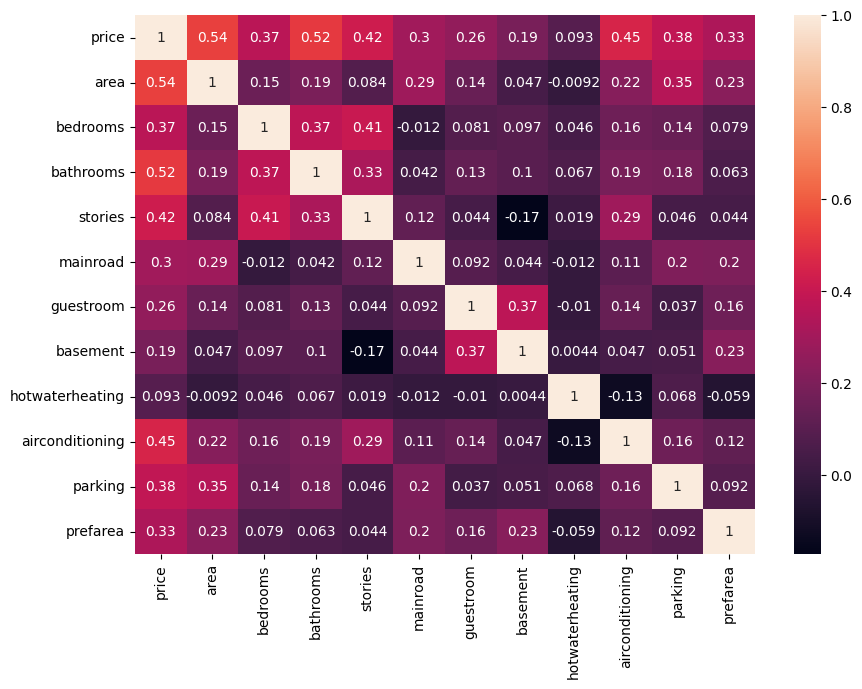

In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(data=df.corr(), annot=True)

In [7]:
x = df.iloc[:, 1:]
y = df.iloc[:, :1]

In [8]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns = x.columns)
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941
1,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035
2,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941
3,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941
4,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [10]:
ri = Ridge(alpha=0.5)
ri.fit(x_train, y_train)
ri.score(x_test, y_test)*100

65.4936989994304

In [11]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

1590135644878.5745
917985.9379715767
1261005.8068377697


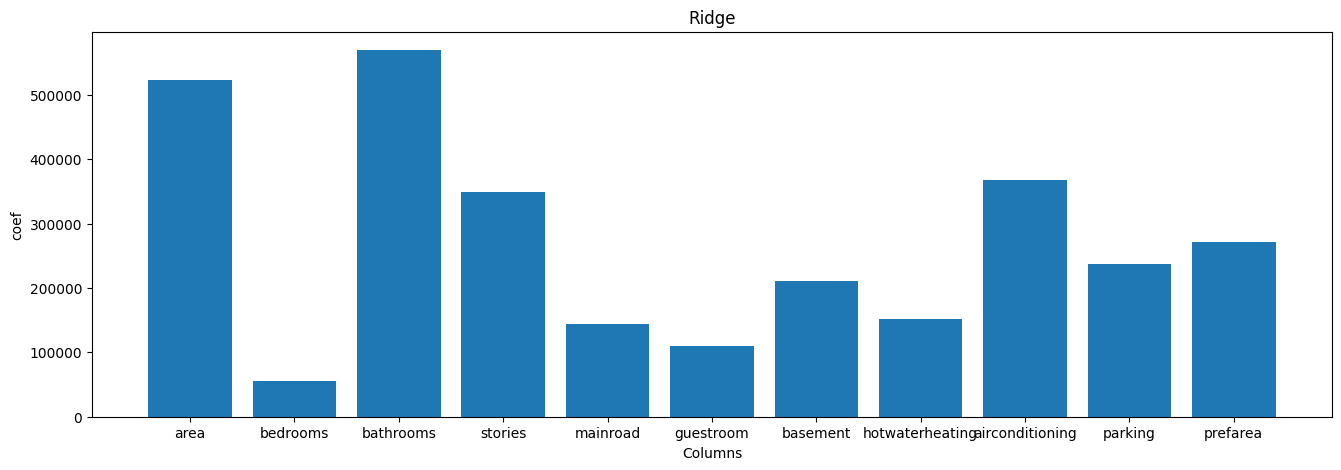

In [12]:
plt.figure(figsize=(16, 5))
plt.bar(x.columns, ri.coef_.ravel())
plt.title("Ridge")
plt.xlabel("Columns")
plt.ylabel("coef")
plt.show()

In [13]:
dfa = pd.DataFrame({"col_name":x.columns, "Ridge":ri.coef_.ravel()})
dfa

,col_name,Ridge
0,area,523795.450357
1,bedrooms,56037.734242
2,bathrooms,569584.353335
3,stories,348312.332721
4,mainroad,144420.557514
5,guestroom,109913.071141
6,basement,210536.536009
7,hotwaterheating,152429.097289
8,airconditioning,367523.122836
9,parking,236537.276924


In [14]:
# At above we can show Lasso have high Accureccy than other so here we are use Lasso